<style>
.jp-Notebook,
.jp-NotebookPanel-notebook,
main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon p,
.text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}

.jp-OutputArea-output img,
.jp-RenderedImage img,
.output_png img,
div.output_area img,
div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}

.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}

.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}

.interpretation-label {
    font-style: italic;
    font-weight: 600;
}
</style>

# The Itô Integral: From Integrand to Process

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 3015

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
PURPLE = "#8E6C8A"
GREY = "#6B7280"
LIGHT_GREY = "#D1D5DB"
INK = "#1F2937"


def brownian_paths(rng, path_count, interval_count, horizon=1.0):
    dt = horizon / interval_count
    increments = np.sqrt(dt) * rng.standard_normal((path_count, interval_count))
    paths = np.concatenate([np.zeros((path_count, 1)), np.cumsum(increments, axis=1)], axis=1)
    return increments, paths


def coarse_left_coefficients(path, coarse_count):
    fine_count = len(path) - 1
    block = fine_count // coarse_count
    if fine_count % coarse_count:
        raise ValueError("The coarse grid must divide the fine grid.")
    return np.repeat(path[::block][:-1], block)

## 1. Simple adapted processes define the integral pathwise

Fix $T>0$, a Brownian motion $(B_t)_{t\in[0,T]}$, and its standard Brownian filtration $(\mathcal F_t)$. In the course notation, a simple adapted integrand has the form

$$
f(t,\omega)=\sum_{i=0}^{n-1}a_i(\omega)\mathbf 1_{(t_i,t_{i+1}]}(t),
\qquad
a_i\in L^2(\Omega,\mathcal F_{t_i},P).
$$

The coefficient $a_i$ is known at the left endpoint, so it cannot depend on the next Brownian increment. The terminal Itô integral is defined by

$$
I(f)=\int_0^T f_s\,dB_s
=\sum_{i=0}^{n-1}a_i(B_{t_{i+1}}-B_{t_i}).
$$

For every $t$, truncating the last increment gives a continuous process:

$$
X_t=\int_0^t f_s\,dB_s.
$$

The experiment uses $a_i=0.5+B_{t_i}$, which is $\mathcal F_{t_i}$-measurable.

Terminal integral from fine partial increments: -0.132219
Terminal defining sum: -0.132219


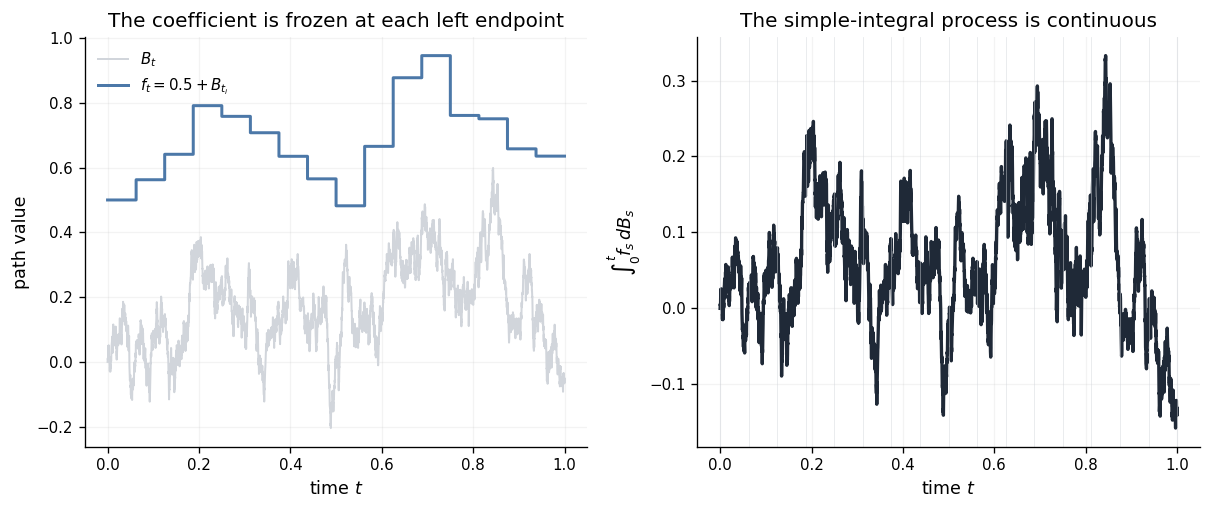

In [2]:
rng = np.random.default_rng(SEED + 10)
T = 1.0
fine_count = 4_096
coarse_count = 16
dt = T / fine_count
time = np.linspace(0.0, T, fine_count + 1)
dB = np.sqrt(dt) * rng.standard_normal(fine_count)
B = np.concatenate([[0.0], np.cumsum(dB)])
block = fine_count // coarse_count
left_values = B[::block][:-1]
simple_f = np.repeat(0.5 + left_values, block)
ito_process = np.concatenate([[0.0], np.cumsum(simple_f * dB)])

print(f"Terminal integral from fine partial increments: {ito_process[-1]:+.6f}")
print(f"Terminal defining sum: {np.sum((0.5 + left_values) * dB.reshape(coarse_count, block).sum(axis=1)):+.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(time, B, color=LIGHT_GREY, linewidth=1.2, label=r"$B_t$")
axes[0].step(time[:-1], simple_f, where="post", color=BLUE, linewidth=1.8, label=r"$f_t=0.5+B_{t_i}$")
axes[0].set_title("The coefficient is frozen at each left endpoint")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel("path value")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(time, ito_process, color=INK, linewidth=2.0)
for t_i in time[::block]:
    axes[1].axvline(t_i, color=LIGHT_GREY, linewidth=0.45, alpha=0.6)
axes[1].set_title("The simple-integral process is continuous")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel(r"$\int_0^t f_s\,dB_s$")
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> One Brownian path, a 16-step adapted integrand, and the resulting cumulative Itô integral on $[0,1]$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The integrand changes only when a new left-endpoint observation becomes available. Within each interval its coefficient stays fixed, while the integral evolves continuously with the current Brownian increment. The terminal value agrees with the defining finite sum to floating-point precision.</p>

## 2. Itô isometry extends the terminal integral by completion

Let $H_0^2$ denote the simple adapted processes and let $H^2$ be the adapted processes in $L^2([0,T]\times\Omega)$. For $f\in H_0^2$, the Itô isometry states

$$
\|I(f)\|_{L^2(\Omega)}
=\|f\|_{L^2([0,T]\times\Omega)},
$$

or equivalently

$$
E\left[\left(\int_0^T f_s\,dB_s\right)^2\right]
=E\left[\int_0^T f_s^2\,ds\right].
$$

Because $H_0^2$ is dense in $H^2$, the isometry sends an approximating Cauchy sequence of integrands to a Cauchy sequence in $L^2(\Omega)$. This defines $I(f)$ for every $f\in H^2$ and preserves the same norm identity.

For deterministic $f$, the integral is Gaussian with variance $\int_0^T f_s^2\,ds$. The simulation below samples that exact Brownian-sum law for four integrands.

 integrand      input energy      output second moment
 constant        1.000000             1.008169
 linear          1.000000             1.009472
 sine            1.245000             1.245350
 pulse           1.213929             1.213150
Largest relative discrepancy: 0.947%


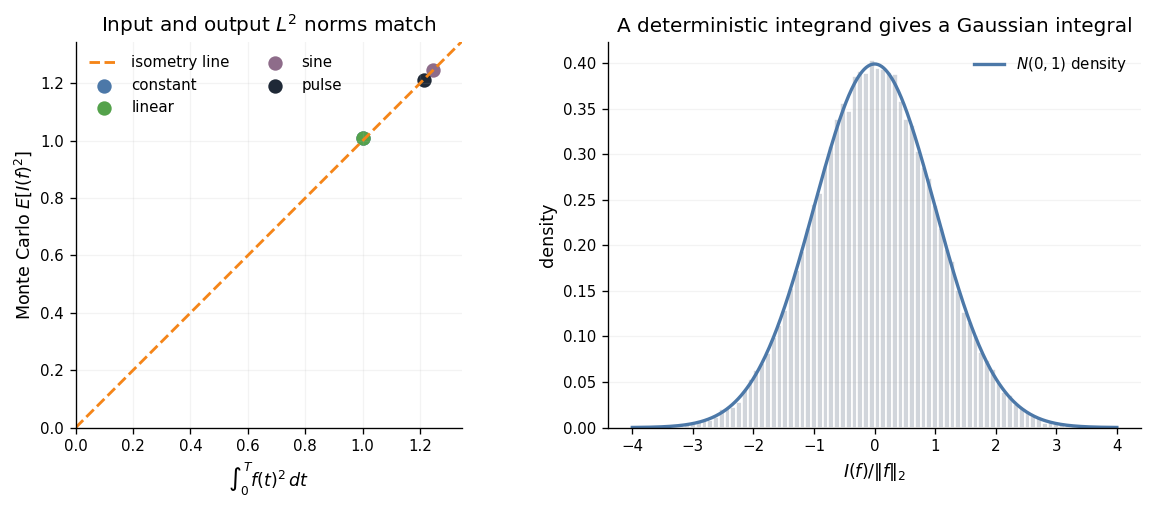

In [3]:
rng = np.random.default_rng(SEED + 11)
grid = (np.arange(2_048) + 0.5) / 2_048
dt_iso = 1.0 / len(grid)
integrands = {
    "constant": np.ones_like(grid),
    "linear": np.sqrt(3.0) * grid,
    "sine": 1.0 + 0.7 * np.sin(2.0 * np.pi * grid),
    "pulse": np.where(grid < 0.35, 1.8, 0.35),
}
n_mc = 80_000
energies = np.array([np.sum(values**2) * dt_iso for values in integrands.values()])
terminal_draws = {
    name: np.sqrt(energy) * rng.standard_normal(n_mc)
    for (name, _), energy in zip(integrands.items(), energies)
}
second_moments = np.array([np.mean(draws**2) for draws in terminal_draws.values()])
relative_error = np.max(np.abs(second_moments / energies - 1.0))

print(" integrand      input energy      output second moment")
for name, energy, moment in zip(integrands, energies, second_moments):
    print(f" {name:<10s}      {energy:>8.6f}             {moment:>8.6f}")
print(f"Largest relative discrepancy: {relative_error:.3%}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

limit = 1.08 * max(np.max(energies), np.max(second_moments))
axes[0].plot([0.0, limit], [0.0, limit], color=ORANGE, linestyle="--", linewidth=1.7, label="isometry line")
for name, x_value, y_value, color in zip(integrands, energies, second_moments, [BLUE, GREEN, PURPLE, INK]):
    axes[0].scatter(x_value, y_value, s=58, color=color, label=name)
axes[0].set_xlim(0.0, limit)
axes[0].set_ylim(0.0, limit)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Input and output $L^2$ norms match")
axes[0].set_xlabel(r"$\int_0^T f(t)^2\,dt$")
axes[0].set_ylabel(r"Monte Carlo $E[I(f)^2]$")
axes[0].legend(frameon=False, ncol=2)
axes[0].grid(alpha=0.14)

pulse_draws = terminal_draws["pulse"]
standardized = pulse_draws / np.sqrt(energies[-1])
hist_bins = np.linspace(-4.0, 4.0, 85)
axes[1].hist(standardized, bins=hist_bins, density=True, color=LIGHT_GREY, edgecolor="white")
x_density = np.linspace(-4.0, 4.0, 500)
normal_density = np.exp(-0.5 * x_density**2) / np.sqrt(2.0 * np.pi)
axes[1].plot(x_density, normal_density, color=BLUE, linewidth=2.0, label=r"$N(0,1)$ density")
axes[1].set_title("A deterministic integrand gives a Gaussian integral")
axes[1].set_xlabel(r"$I(f)/\|f\|_2$")
axes[1].set_ylabel("density")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 2.</strong> Input energies and Monte Carlo second moments for four deterministic integrands, together with the standardized terminal law for the pulse integrand; each experiment uses $80{,}000$ draws.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The points lie on the isometry line, so changing the shape of a deterministic integrand changes the output variance only through its $L^2$ energy. After division by that norm, the pulse integral follows the standard Gaussian benchmark. The theorem gives the exact identity; the simulation reports finite-sample agreement.</p>

## 3. The indefinite integral has a continuous martingale version

For $f\in H^2$, the terminal map alone gives an $L^2$ equivalence class $I(\mathbf 1_{[0,t]}f)$ at each fixed $t$. Theorem 4.10 constructs a single continuous martingale $(X_t)_{t\in[0,T]}$ satisfying

$$
P\left(X_t=I(\mathbf 1_{[0,t]}f)\right)=1
\qquad\text{for every }t\in[0,T].
$$

The construction approximates $f$ by simple processes $f_n$, forms the continuous martingales

$$
X_t^{(n)}=I(\mathbf 1_{[0,t]}f_n),
$$

and extracts an almost surely uniformly convergent subsequence. The limit supplies one coherent continuous version across the uncountable time interval.

For $f_s=B_s$, Example 4.12 gives the benchmark

$$
\int_0^t B_s\,dB_s=\frac{B_t^2-t}{2}.
$$

Target terminal integral: -0.185733
N= 16: terminal=+0.069038, sup error=0.275117
N= 64: terminal=-0.064551, sup error=0.125377
N=256: terminal=-0.207923, sup error=0.034502


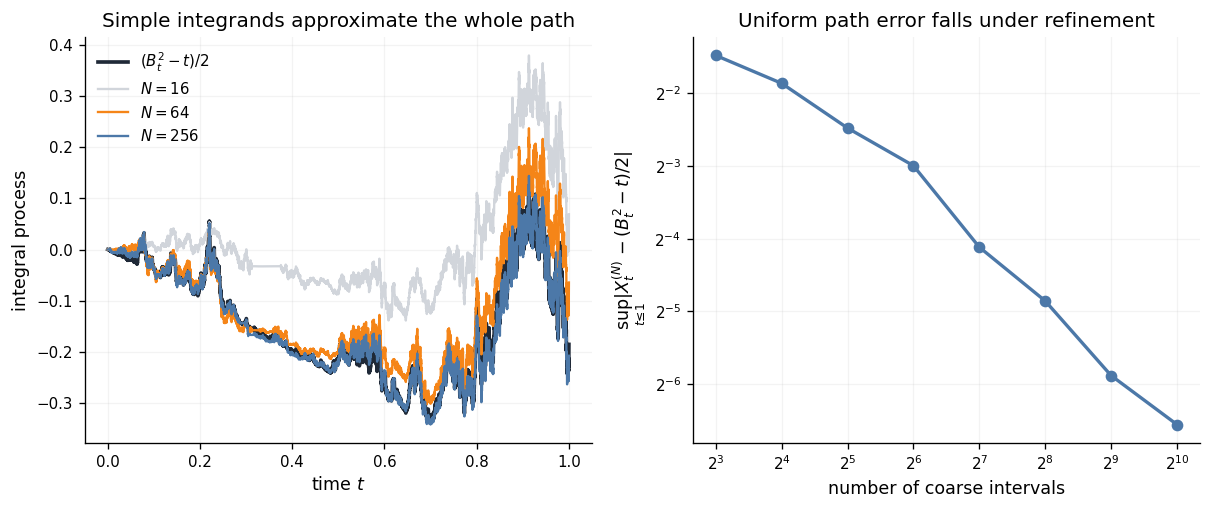

In [4]:
rng = np.random.default_rng(SEED + 12)
fine_count = 8_192
dt = T / fine_count
time = np.linspace(0.0, T, fine_count + 1)
dB = np.sqrt(dt) * rng.standard_normal(fine_count)
B = np.concatenate([[0.0], np.cumsum(dB)])
target = 0.5 * (B**2 - time)

approximation_counts = [16, 64, 256]
approximation_paths = {}
for count in approximation_counts:
    coefficients = coarse_left_coefficients(B, count)
    approximation_paths[count] = np.concatenate([[0.0], np.cumsum(coefficients * dB)])

error_counts = 2 ** np.arange(3, 11)
sup_errors = []
for count in error_counts:
    coefficients = coarse_left_coefficients(B, count)
    approximation = np.concatenate([[0.0], np.cumsum(coefficients * dB)])
    sup_errors.append(np.max(np.abs(approximation - target)))

print(f"Target terminal integral: {target[-1]:+.6f}")
for count in approximation_counts:
    print(f"N={count:>3d}: terminal={approximation_paths[count][-1]:+.6f}, sup error={np.max(np.abs(approximation_paths[count] - target)):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(time, target, color=INK, linewidth=2.2, label=r"$(B_t^2-t)/2$")
for count, color in zip(approximation_counts, [LIGHT_GREY, ORANGE, BLUE]):
    axes[0].plot(time, approximation_paths[count], color=color, linewidth=1.4, label=rf"$N={count}$")
axes[0].set_title("Simple integrands approximate the whole path")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel(r"integral process")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(error_counts, sup_errors, marker="o", color=BLUE, linewidth=2.0)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log", base=2)
axes[1].set_title("Uniform path error falls under refinement")
axes[1].set_xlabel("number of coarse intervals")
axes[1].set_ylabel(r"$\sup_{t\leq1}|X_t^{(N)}-(B_t^2-t)/2|$")
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 3.</strong> Left-point simple-process approximations to $\int_0^t B_s\,dB_s$ on one Brownian path and their sup-norm errors relative to the closed form.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Refinement improves the entire cumulative path rather than only its endpoint. The plotted sequence is a numerical approximation on one trajectory; Theorem 4.10 supplies the continuous martingale version for a general $H^2$ integrand.</p>

## 4. Doob control turns terminal $L^2$ error into path control

For two simple approximations, $M_t=X_t^{(n)}-X_t^{(m)}$ is a martingale. Doob's $L^2$ inequality and Itô isometry give

$$
E\left[\sup_{0\leq t\leq T}|M_t|^2\right]
\leq4E|M_T|^2
=4\|f_n-f_m\|_{L^2([0,T]\times\Omega)}^2.
$$

Consequently, convergence of integrands in $H^2$ controls the whole integral path in probability. The constant four is essential in this squared-norm form.

The experiment compares the left-point approximation of $f_s=B_s$ on several coarse grids with a fixed fine-grid approximation. Every difference is a discrete-time martingale on the fine grid, so the same maximal inequality applies to the simulated sums.

 N      E[terminal error^2]      E[sup error^2]      ratio
  8           0.0614243            0.1102044        1.794
 16           0.0303201            0.0536590        1.770
 32           0.0148577            0.0259372        1.746
 64           0.0068901            0.0118864        1.725
128           0.0028929            0.0050232        1.736
Largest empirical ratio: 1.794 (Doob bound: 4)


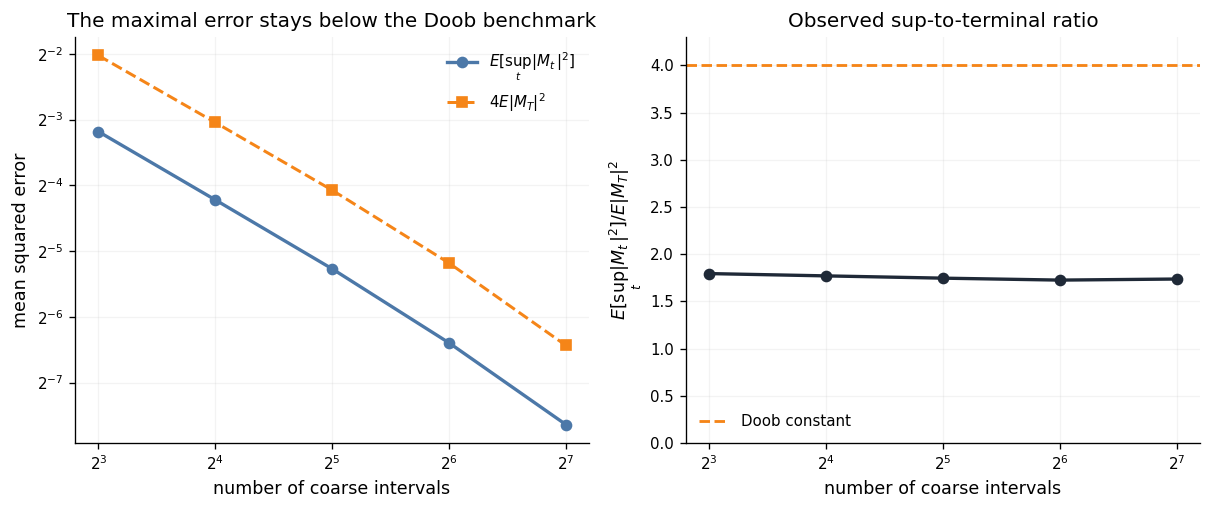

In [5]:
rng = np.random.default_rng(SEED + 13)
n_paths = 6_000
fine_count = 512
dt = T / fine_count
dB, B_paths = brownian_paths(rng, n_paths, fine_count, T)
fine_coefficients = B_paths[:, :-1]
fine_integrals = np.cumsum(fine_coefficients * dB, axis=1)

coarse_counts = np.array([8, 16, 32, 64, 128])
terminal_second_moments = []
sup_second_moments = []
ratios = []

for count in coarse_counts:
    block = fine_count // count
    coarse_coefficients = np.repeat(B_paths[:, ::block][:, :-1], block, axis=1)
    coarse_integrals = np.cumsum(coarse_coefficients * dB, axis=1)
    difference = coarse_integrals - fine_integrals
    terminal_ms = np.mean(difference[:, -1] ** 2)
    sup_ms = np.mean(np.max(np.abs(difference), axis=1) ** 2)
    terminal_second_moments.append(terminal_ms)
    sup_second_moments.append(sup_ms)
    ratios.append(sup_ms / terminal_ms)

terminal_second_moments = np.asarray(terminal_second_moments)
sup_second_moments = np.asarray(sup_second_moments)
ratios = np.asarray(ratios)

print(" N      E[terminal error^2]      E[sup error^2]      ratio")
for count, terminal_ms, sup_ms, ratio in zip(coarse_counts, terminal_second_moments, sup_second_moments, ratios):
    print(f"{count:>3d}          {terminal_ms:>10.7f}           {sup_ms:>10.7f}       {ratio:>6.3f}")
print(f"Largest empirical ratio: {ratios.max():.3f} (Doob bound: 4)")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(coarse_counts, sup_second_moments, marker="o", color=BLUE, linewidth=2.0, label=r"$E[\sup_t|M_t|^2]$")
axes[0].plot(coarse_counts, 4.0 * terminal_second_moments, marker="s", color=ORANGE, linestyle="--", linewidth=1.8, label=r"$4E|M_T|^2$")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=2)
axes[0].set_title("The maximal error stays below the Doob benchmark")
axes[0].set_xlabel("number of coarse intervals")
axes[0].set_ylabel("mean squared error")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(coarse_counts, ratios, marker="o", color=INK, linewidth=2.0)
axes[1].axhline(4.0, color=ORANGE, linestyle="--", linewidth=1.7, label="Doob constant")
axes[1].set_xscale("log", base=2)
axes[1].set_ylim(0.0, 4.3)
axes[1].set_title("Observed sup-to-terminal ratio")
axes[1].set_xlabel("number of coarse intervals")
axes[1].set_ylabel(r"$E[\sup_t|M_t|^2]/E|M_T|^2$")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 4.</strong> Monte Carlo terminal and maximal errors for coarse approximations of the $B_s$ integrand relative to a 512-step reference, using $6{,}000$ paths.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Both terminal and whole-path errors decrease as the coarse grid is refined. The empirical maximal error remains below four times the terminal error, matching the theorem's direction. The observed ratios are sample quantities, while Doob's inequality provides the exact upper bound.</p>

## 5. Localization extends the integral beyond global $H^2$

The course defines $L^2_{\mathrm{loc}}([0,T])$ as the adapted processes $f$ satisfying

$$
\int_0^T|f_s|^2\,ds<\infty
\qquad\text{almost surely}.
$$

This pathwise condition does not require the expectation of the integral to be finite. Define

$$
\tau_n=\inf\left\{t\geq0:\int_0^t|f_s|^2\,ds\geq n\right\}\wedge T,
\qquad
f^{(n)}_s=f_s\mathbf 1_{\{s\leq\tau_n\}}.
$$

Then $f^{(n)}\in H^2$, and the stopped integral processes agree whenever their stopping regions overlap. They therefore patch together into $\int_0^t f_s\,dB_s$.

For $f_s=\exp(B_s^2)$, Brownian path continuity makes the energy finite on every finite horizon almost surely. However, $E[\exp(2B_s^2)]$ is infinite for $s\geq1/4$, so this integrand is not in global $H^2$ on $[0,1]$.

Selected path energy at T: 110.334936
n= 2.0: discrete stopping time 0.561768
n= 5.0: discrete stopping time 0.700195
n=10.0: discrete stopping time 0.727051


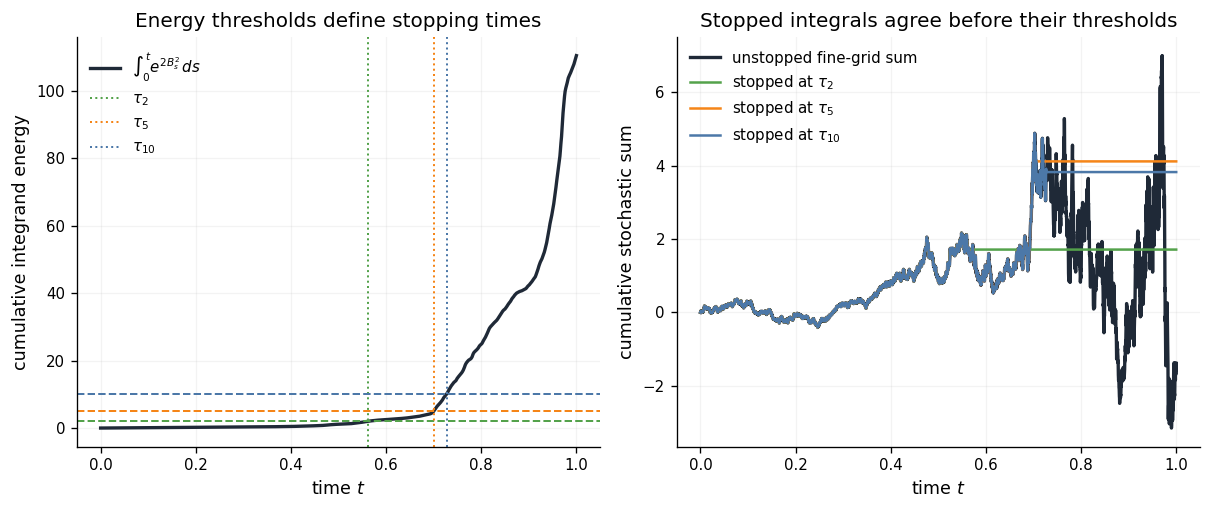

In [6]:
rng = np.random.default_rng(SEED + 14)
fine_count = 4_096
dt = T / fine_count
candidate_count = 96
candidate_dB, candidate_B = brownian_paths(rng, candidate_count, fine_count, T)
candidate_f = np.exp(np.minimum(candidate_B[:, :-1] ** 2, 25.0))
candidate_energy = np.sum(candidate_f**2, axis=1) * dt
eligible = np.flatnonzero(candidate_energy > 12.0)
selected = int(eligible[0]) if len(eligible) else int(np.argmax(candidate_energy))

dB = candidate_dB[selected]
B = candidate_B[selected]
f_values = candidate_f[selected]
energy_curve = np.concatenate([[0.0], np.cumsum(f_values**2 * dt)])
full_integral = np.concatenate([[0.0], np.cumsum(f_values * dB)])
time = np.linspace(0.0, T, fine_count + 1)
levels = np.array([2.0, 5.0, 10.0])
stopped_integrals = {}
stop_times = {}

for level in levels:
    stop_index = min(np.searchsorted(energy_curve, level, side="left"), fine_count)
    stopped_coefficients = f_values.copy()
    stopped_coefficients[stop_index:] = 0.0
    stopped_integrals[level] = np.concatenate([[0.0], np.cumsum(stopped_coefficients * dB)])
    stop_times[level] = time[stop_index]

print(f"Selected path energy at T: {energy_curve[-1]:.6f}")
for level in levels:
    print(f"n={level:>4.1f}: discrete stopping time {stop_times[level]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(time, energy_curve, color=INK, linewidth=2.0, label=r"$\int_0^t e^{2B_s^2}\,ds$")
for level, color in zip(levels, [GREEN, ORANGE, BLUE]):
    axes[0].axhline(level, color=color, linestyle="--", linewidth=1.2)
    axes[0].axvline(stop_times[level], color=color, linestyle=":", linewidth=1.2, label=rf"$\tau_{{{level:g}}}$")
axes[0].set_title("Energy thresholds define stopping times")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel("cumulative integrand energy")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(time, full_integral, color=INK, linewidth=2.0, label="unstopped fine-grid sum")
for level, color in zip(levels, [GREEN, ORANGE, BLUE]):
    axes[1].plot(time, stopped_integrals[level], color=color, linewidth=1.5, label=rf"stopped at $\tau_{{{level:g}}}$")
axes[1].set_title("Stopped integrals agree before their thresholds")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel("cumulative stochastic sum")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 5.</strong> Cumulative energy and stopped stochastic sums for $f_s=\exp(B_s^2)$ on one selected Brownian path; the grid has $4{,}096$ intervals.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Each threshold freezes the corresponding integral after its energy reaches $n$. Before that stopping time the stopped and unstopped sums coincide, so larger thresholds extend the same local construction. The selected high-energy path makes the patching visible; it is not a frequency statement about typical Brownian paths.</p>

## References

- *MATH3015: Stochastic Processes*, Chapter 4, Definition 4.1, Lemma 4.2, Definition 4.4, Theorem 4.10, Example 4.12, and Definitions 4.15-4.17.
- Fima C. Klebaner, *Introduction to Stochastic Calculus with Applications*, 3rd ed., Chapter 4, Sections 4.1-4.3.